## Notebook by Karol Rejek

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
import pandas as pd
import numpy as np
from pathlib import Path

base_path = Path('content/drive/MyDrive/DataSets')
data_path = '/content/drive/MyDrive/DataSets/titanic.csv'
titanic_df = pd.read_csv(data_path, index_col='PassengerId')

def count_outliers_iqr(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    mask = (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)
    return mask.sum()

## Wstępny przegląd danych

Zanim ruszę z jakimkolwiek feature engineeringiem, sprawdzam z czym pracuję: strukturę, typy danych, braki i duplikaty.

In [63]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [65]:
titanic_df.describe(include='all')

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,793.000000,204,889
unique,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,1601,NaN,G6,S
freq,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,33.123938,NaN,NaN
std,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,51.578312,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.925000,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.500000,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN


In [66]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,98
Cabin,687


In [67]:
titanic_df.duplicated().sum()

np.int64(0)

## Ekstrakcja Title z Name

Kolumna Name zawiera tytuł (Mr, Mrs, Miss, Master, ...), które wyciągam do kolumny SocialGroup.

In [68]:
titanic_df['SocialStatus'] = titanic_df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()

socialStatus_map = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
titanic_df['SocialStatus'] = titanic_df['SocialStatus'].replace(socialStatus_map)

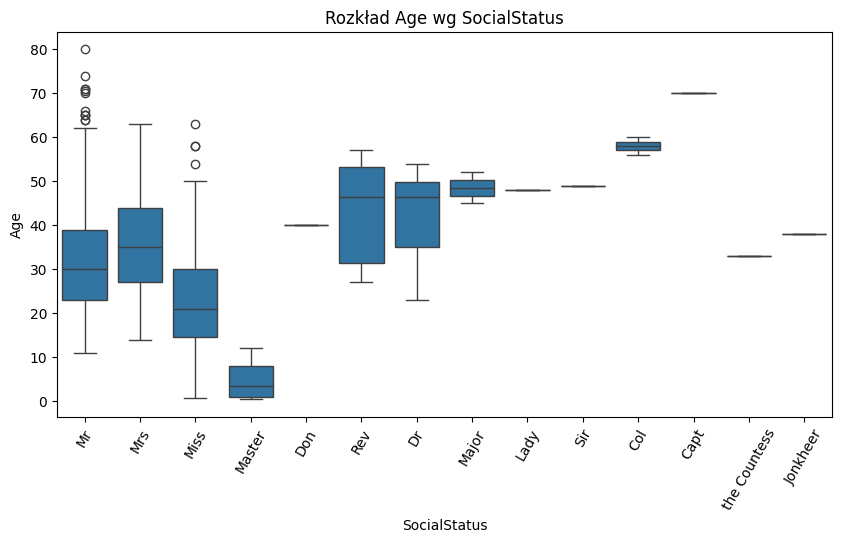

In [69]:
plt.figure(figsize=(10,5))
sns.boxplot(data=titanic_df, x='SocialStatus', y='Age')
plt.xticks(rotation=60)
plt.title('Rozkład Age wg SocialStatus')
plt.show()

## Podział na train/test

Od tego miejsca każda statystyka używana do imputacji lub walidacji liczona jest
wyłącznie na train_df i aplikowana identycznie na test_df.

In [70]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(titanic_df, test_size=0.2, stratify=titanic_df['Survived'], random_state=42)

### Imputacja wieku (`Age`) na podstawie tytułu (`Title`)

Brakujące wartości w kolumnie `Age` uzupełniłem medianą wieku wyliczoną **osobno dla każdej grupy `Title`** (np. Mr, Mrs, Miss, Master, Dr, Rev...).
Można zauwarzyć że w danych kolumana `Name` zawiera takie inforamacjie jak: imię, nazwisko, status społeczny czy przezwisko. Wydobycie informacji z kolumny `Name` o statusie społecznym danego pasarzera pozwala oszacować wiek w brakujących komurkach w kolumnie `Age` na podstawie wyliczenia mediany z dla danego statusu społecznego danej osoby. Z tego powodu wyodrębniłem status społeczny danje odoby do kolumny `Title` w celu lepszego pogrupowania do wyliczenia mediany. Przed wyliczeniem mediany `Age` ujednoliciłem tożsame warianty językowe tytułów (`Mlle`→`Miss`, `Ms`→`Miss`, `Mme`→`Mrs`), aby nie tworzyć sztucznie rozdrobnionych grup.

In [71]:
train_df.groupby('SocialStatus')['Age'].agg(['median', 'count'])

,median,count
SocialStatus,,
Col,58.0,2
Don,40.0,1
Dr,49.0,5
Jonkheer,38.0,1
Lady,48.0,1
Major,52.0,1
Master,3.0,28
Miss,22.0,118
Mr,30.0,318


In [72]:
age_medians_by_socialStatus = train_df.groupby('SocialStatus')['Age'].median()
global_median_age = train_df['Age'].median()

for df in (train_df, test_df):
    mapped_medians = df['SocialStatus'].map(age_medians_by_socialStatus)
    mapped_medians = mapped_medians.fillna(global_median_age)
    df['Age'] = df['Age'].fillna(mapped_medians)

In [73]:
titanic_df.groupby(['Pclass', titanic_df['Cabin'].isna()])['Survived'].mean()

Pclass  Cabin
1       False    0.664773
        True     0.475000
2       False    0.812500
        True     0.440476
3       False    0.500000
        True     0.235908
Name: Survived, dtype: float64

Decyduję się na usunięcie kolumny `Name`, ponieważ w surowej, tekstowej formie każda wartość jest praktycznie unikalna dla danego pasażera, co nie wnosi żadnej użytecznej informacji predykcyjnej dla modelu, a mogłoby jedynie zwiększyć wymiarowość danych bez korzyści. Najważniejsza informacja zawarta w tej kolumnie — status społeczny pasażera — została już wyekstrahowana do kolumny `SocialStatus`, więc `Name` w dużej mierze duplikuje to, co model może uzyskać z innych, lepiej ustrukturyzowanych cech. Rozważałem również wykorzystanie `Name` do identyfikacji rodzin (np. w połączeniu z `Ticket`, aby oszacować przeżywalność w obrębie rodziny), jednak ostatecznie zrezygnowałem z tego podejścia w ramach tej analizy, co czyni tę kolumnę zbędną w finalnym zbiorze.

In [74]:
for df in (train_df, test_df):
    df.drop(columns=['Name'], inplace=True)

### Kodowanie `SocialStatus`

Ponieważ `SocialStatus` jest zmienną nominalną, to do kodowania stosuję metodę **one-hot** (`pd.get_dummies`). `SocialStatus` wszystkie oryginalne kategorie po wcześniejszym ujednoliceniu językowych wariantów: (Mlle=>Miss, Ms=>Miss, Mme=>Mrs), ponieważ nawet rzadkie tytuły (np. Dr, Rev, Col) mogą nieść istotną informację o statusie społecznym pasażera, wpływającą na przeżywalność. Zastosowanie one-hot encoding nie wprowadza sztucznej kolejności między kategoriami, w przeciwieństwie do kodowania porządkowego, które błędnie sugerowałoby, że jedna kategoria jest "większa" od drugiej.

In [75]:
# Liczebność kategorii SocialStatus
titanic_df['SocialStatus'].value_counts()

,count
SocialStatus,
Mr,517
Miss,185
Mrs,126
Master,40
Dr,7
Rev,6
Col,2
Major,2
Don,1


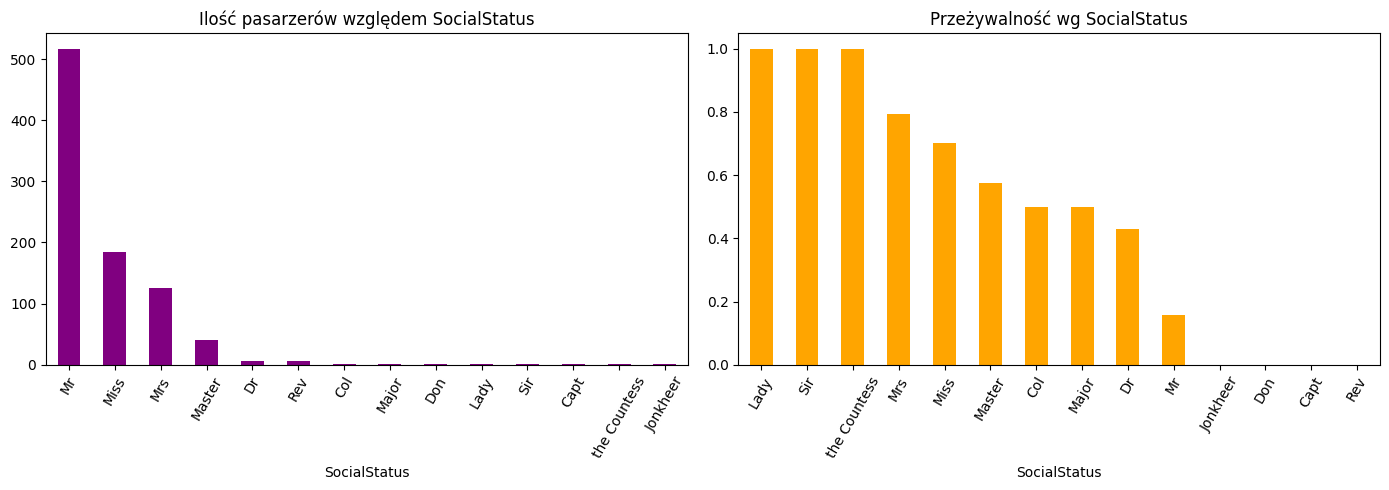

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
titanic_df['SocialStatus'].value_counts().plot(kind='bar', ax=axes[0], color='purple')
axes[0].set_title('Ilość pasarzerów względem SocialStatus')
axes[0].tick_params(axis='x', rotation=60)

titanic_df.groupby('SocialStatus')['Survived'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Przeżywalność wg SocialStatus')
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

Ze względu na rozkład danych zastępuję kolumnę SocialStatus na SocialGrup, która to lepiej oddaje przypisanie pasarzerów do poszczegulnych klas społecznych. Dzięki czemy umożliwiam modelowi dokładniejszą klasyfikację.

In [77]:
socialGroup_map = {
    'Mr': 'Commoner', 'Mrs': 'Commoner', 'Miss': 'Commoner', 'Master': 'Commoner',
    'Dr': 'Professional/Clergy', 'Rev': 'Professional/Clergy',
    'Col': 'Military/Nobility', 'Major': 'Military/Nobility', 'Capt': 'Military/Nobility',
    'Don': 'Military/Nobility', 'Lady': 'Military/Nobility', 'Sir': 'Military/Nobility',
    'the Countess': 'Military/Nobility', 'Jonkheer': 'Military/Nobility',
}

titanic_df['SocialGroup'] = titanic_df['SocialStatus'].map(socialGroup_map)

unmapped = titanic_df.loc[titanic_df['SocialGroup'].isna(), 'SocialStatus'].unique()
assert len(unmapped) == 0, f"Niezmapowane tytuły: {unmapped}"

In [78]:
group_order = ['Commoner', 'Professional/Clergy', 'Military/Nobility']
titanic_df['SocialGroup'] = pd.Categorical(titanic_df['SocialGroup'], categories=group_order, ordered=True)

titanic_df['SocialGroup'].value_counts()

,count
SocialGroup,
Commoner,868
Professional/Clergy,13
Military/Nobility,10


In [79]:
train_df['SocialGroup'] = train_df['SocialStatus'].map(socialGroup_map)
train_df['SocialGroup'] = pd.Categorical(train_df['SocialGroup'], categories=group_order, ordered=True)

test_df['SocialGroup'] = test_df['SocialStatus'].map(socialGroup_map)
test_df['SocialGroup'] = pd.Categorical(test_df['SocialGroup'], categories=group_order, ordered=True)

In [80]:
pd.crosstab(train_df['SocialGroup'], train_df['Pclass'], margins=True)

Pclass,1,2,3,All
SocialGroup,,,,
Commoner,160,143,391,694
Professional/Clergy,4,7,0,11
Military/Nobility,7,0,0,7
All,171,150,391,712


In [81]:
train_df.groupby('SocialGroup', observed=True)['Survived'].agg(['mean', 'count'])

,mean,count
SocialGroup,,
Commoner,0.383285,694
Professional/Clergy,0.272727,11
Military/Nobility,0.571429,7


Zmiana kodowania `SocialGrup` na One-Hot

In [82]:
for df in (train_df, test_df):
    df.drop(columns=['SocialStatus'], inplace=True)

train_df = pd.get_dummies(train_df, columns=['SocialGroup'], prefix='SocialGroup', drop_first=True)
test_df = pd.get_dummies(test_df, columns=['SocialGroup'], prefix='SocialGroup', drop_first=True)

assert set(train_df.columns) - set(test_df.columns) == set(), "Niezgodność kolumn po one-hot!"

### Rekonstrukcja kolumn SibSp + Parch

Sprawdziłem osobno związek `SibSp` i `Parch` z przeżywalnością przed ich połączeniem. Obie kolumny mają podobny, nieliniowy kształt - wzrost przy małej liczbie towarzyszy, spadek przy większej (szczyty: SibSp=1 => 53,6%, Parch=3 => 60,0%), przy czym wartości dla większych liczb opierają się na małych próbkach. Podobieństwo wzorców uzasadnia połączenie obu kolumn w jedną cechę.

In [83]:
train_df.groupby('SibSp')['Survived'].mean()

,Survived
SibSp,
0,0.344130
1,0.536585
2,0.523810
3,0.100000
4,0.200000
5,0.000000
8,0.000000


In [84]:
train_df.groupby('Parch')['Survived'].mean()

,Survived
Parch,
0,0.341328
1,0.542553
2,0.540984
3,0.600000
4,0.000000
5,0.200000
6,0.000000


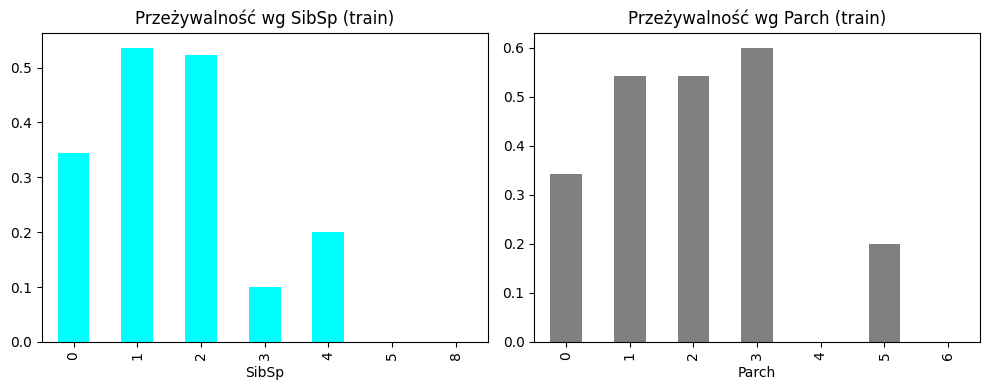

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train_df.groupby('SibSp')['Survived'].mean().plot(kind='bar', ax=axes[0], color='cyan')
axes[0].set_title('Przeżywalność wg SibSp (train)')
train_df.groupby('Parch')['Survived'].mean().plot(kind='bar', ax=axes[1], color='gray')
axes[1].set_title('Przeżywalność wg Parch (train)')
plt.tight_layout()
plt.show()

Zbadałem przeżywalność względem `FamilySize` (`SibSp + Parch + 1`) oraz liczebności poszczególnych grup. Zależność ma kształt odwróconej paraboli - szczyt 72,4% przy `FamilySize=4`, a spadek widoczny jest zarówno dla mniejszych, jak i większych wartości. Grupy 7, 8 i 11 liczą zaledwie 12, 6 i 7 obserwacji, co jest niewiarygodne statystycznie i uzasadnia zbinowanie tej zmiennej.

In [86]:
for df in (train_df, test_df):
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [87]:
train_df.groupby('FamilySize')['Survived'].agg(['mean', 'count'])

,mean,count
FamilySize,,
1,0.299539,434
2,0.550388,129
3,0.623377,77
4,0.727273,22
5,0.214286,14
6,0.062500,16
7,0.363636,11
8,0.000000,4
11,0.000000,5


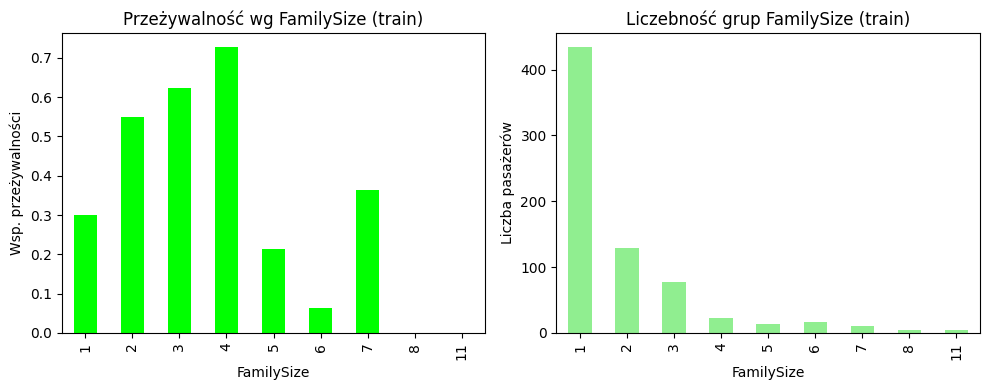

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train_df.groupby('FamilySize')['Survived'].mean().plot(kind='bar', ax=axes[0], color='lime')
axes[0].set_title('Przeżywalność wg FamilySize (train)')
axes[0].set_ylabel('Wsp. przeżywalności')

train_df['FamilySize'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Liczebność grup FamilySize (train)')
axes[1].set_ylabel('Liczba pasażerów')

plt.tight_layout()
plt.show()

Zbadałem zależność między `FamilySize` a przeżywalnością i doszedłem do wniosku, że lepiej zmienić kalumnę na `FamilySizeCategory` (`Alone`=1, `Small`=2–4, `Large`=5+) oraz usunąć `SibSp` i `Parch`. Zmiana ta pozwala lepiej skategoryzować zmienną.

In [89]:
family_bins = [0, 1, 4, np.inf]
family_labels = ['Alone', 'Small', 'Large']

for df in (train_df, test_df):
    df['FamilySizeCategory'] = pd.cut(df['FamilySize'], bins=family_bins, labels=family_labels)
    df['FamilySizeCategory'] = pd.Categorical(df['FamilySizeCategory'], categories=family_labels, ordered=True)
    df.drop(columns=['SibSp', 'Parch'], inplace=True)

In [90]:
train_df.groupby('FamilySizeCategory', observed=True)['Survived'].agg(['mean', 'count'])

,mean,count
FamilySizeCategory,,
Alone,0.299539,434
Small,0.592105,228
Large,0.160000,50


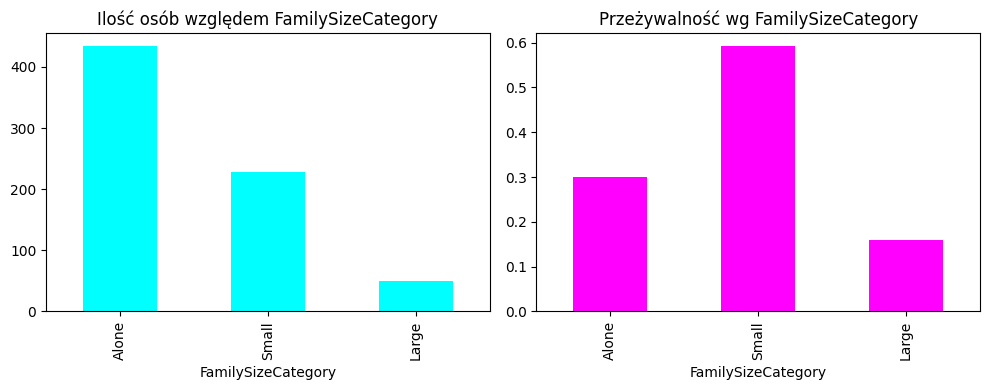

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train_df['FamilySizeCategory'].value_counts().plot(kind='bar', ax=axes[0], color='cyan')
axes[0].set_title('Ilość osób względem FamilySizeCategory')

train_df.groupby('FamilySizeCategory', observed=True)['Survived'].mean().plot(kind='bar', ax=axes[1], color='magenta')
axes[1].set_title('Przeżywalność wg FamilySizeCategory')

plt.tight_layout()
plt.show()

In [92]:
train_df = pd.get_dummies(train_df, columns=['FamilySizeCategory'], prefix='FamilySizeCategory', drop_first=True)
test_df = pd.get_dummies(test_df, columns=['FamilySizeCategory'], prefix='FamilySizeCategory', drop_first=True)

### Zmiana `Sex` na kodowanie binarne
**`Sex` => kodowanie binarne:** `male=0`, `female=1`


In [93]:
sex_map = {'male': 0, 'female': 1}

for df in (train_df, test_df):
    df['Sex'] = df['Sex'].map(sex_map)

In [94]:
assert train_df['Sex'].isna().sum() == 0
assert test_df['Sex'].isna().sum() == 0
train_df['Sex'].value_counts()

,count
Sex,
0,459
1,253


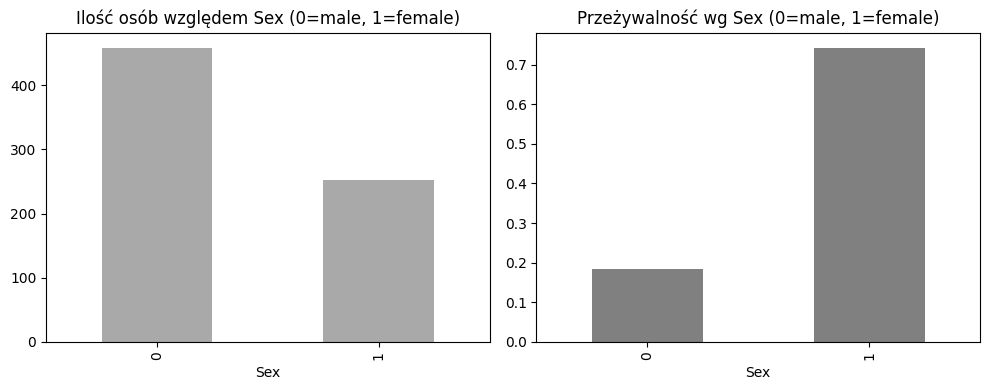

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train_df['Sex'].value_counts().plot(kind='bar', ax=axes[0], color='darkgrey')
axes[0].set_title('Ilość osób względem Sex (0=male, 1=female)')

train_df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1], color='grey')
axes[1].set_title('Przeżywalność wg Sex (0=male, 1=female)')

plt.tight_layout()
plt.show()

### Przetwarzanie `Embarked`
Na samym początku sprawdzam ilość danych i czy nie ma pustych komurek

In [96]:
train_df['Embarked'].value_counts()

,count
Embarked,
S,516
C,139
Q,55


In [97]:
train_df['Embarked'].isna().sum(), test_df['Embarked'].isna().sum()

(np.int64(2), np.int64(0))

Po znalezieniu brakujących pozycji usupełniem je danymi z najczęściej występującymi danymi ponieważ ich liczba nie ma dużego znaczenie w kontekście ilości całości danych.

In [98]:
embarked_mode = train_df['Embarked'].mode()[0]

for df in (train_df, test_df):
    df['Embarked'] = df['Embarked'].fillna(embarked_mode)

Ponieważ `Embarked` to zmienna nominalna przez co porty C, Q, S nie mają naturalnej kolejności, koduję ją metodą one-hot za pomocą `pd.get_dummies`.

In [99]:
train_df = pd.get_dummies(train_df, columns=['Embarked'], prefix='Embarked', drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Embarked'], prefix='Embarked', drop_first=True)

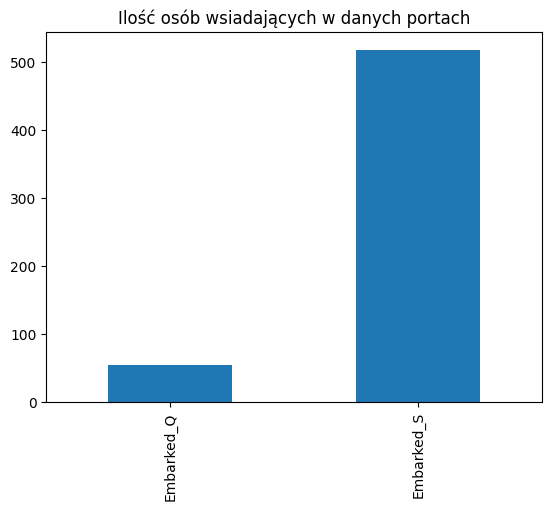

In [100]:
embarked_cols = [c for c in train_df.columns if c.startswith('Embarked_')]

train_df[embarked_cols].sum().plot(kind='bar')
plt.title('Ilość osób wsiadających w danych portach')
plt.show()

### Przetwarzanie `Cabin`
Podczas analizy danych zwróciłem uwagę na to czy `Cabin` ma związek z przeżywalnością pasażerów. W tym cely sprawdziłem jak dane kabiny mają się względem przeżywalności i klas biletów. Po ponirzszym sprawdzeniu doszedłem do wniosku, że litery pokładu w dużej mierze duplikują `Pclass` co można zauwarzyć w poniższych tabelach. Natomiast sam fakt przypisania kabiny okazał się jednak niezależnym predyktorem przeżywalności w obrębie każdej klasy. w związku z tym zmodyfikowałem zastópiłem `Cabin` na binarna `HasCabin` (1 = przypisana kabina, 0 = brak).

In [101]:
deck_train = train_df['Cabin'].str[0]
pd.crosstab(deck_train, train_df['Pclass'], dropna=False)

Pclass,1,2,3
Cabin,,,
A,14,0,0
B,34,0,0
C,41,0,0
D,23,3,0
E,23,4,2
F,0,8,3
G,0,0,4
T,1,0,0
NaN,35,135,382


In [102]:
train_df.groupby(['Pclass', train_df['Cabin'].isna()])['Survived'].mean()

Pclass  Cabin
1       False    0.698529
        True     0.457143
2       False    0.800000
        True     0.407407
3       False    0.555556
        True     0.235602
Name: Survived, dtype: float64

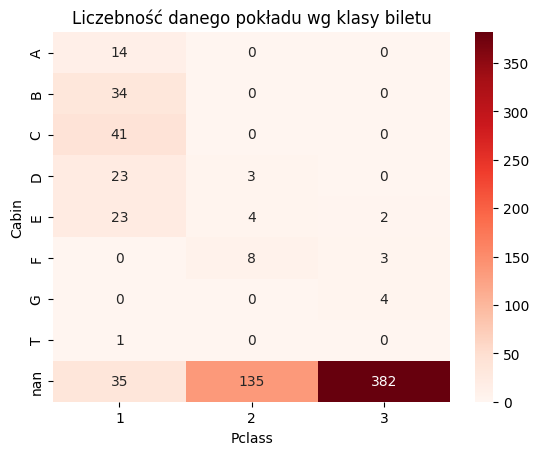

In [103]:
sns.heatmap(pd.crosstab(deck_train, train_df['Pclass'], dropna=False), annot=True, fmt='d', cmap='Reds')
plt.title('Liczebność danego pokładu wg klasy biletu')
plt.show()

In [104]:
for df in (train_df, test_df):
    df['HasCabin'] = df['Cabin'].notna().astype(int)

train_df.groupby('HasCabin')['Survived'].agg(['mean', 'count'])

,mean,count
HasCabin,,
0,0.291667,552
1,0.700000,160


In [105]:
for df in (train_df, test_df):
    df.drop(columns=['Cabin'], inplace=True)

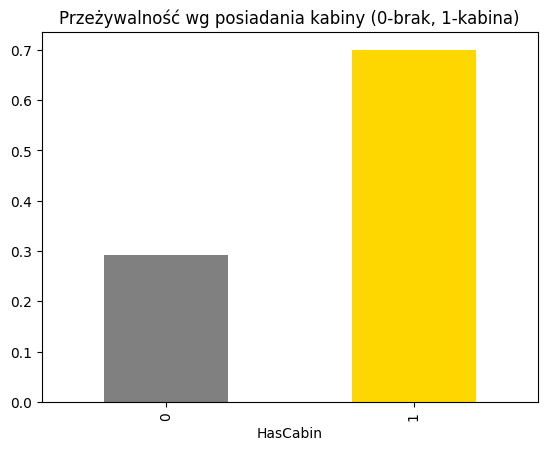

In [106]:
train_df.groupby('HasCabin')['Survived'].mean().plot(kind='bar', color=['gray', 'gold'])
plt.title('Przeżywalność wg posiadania kabiny (0-brak, 1-kabina)')
plt.show()

## Przetwarzanie kolumn `Ticket` i `Fare`

Zwróciłem uwagę, że numer biletu może wskazywać pasażerów podróżujących wspólnie. Dzięki temu mogłem sklasyfikować wielkości grupy biletowej co pozwoliło mi uzupełnie brakujących cen biletów.


`TicketGroupSize`, określa liczbę pasażerów posiadających ten sam numer biletu, co umożliwia wykrycie grup podróżujących razem, również wtedy, gdy nie są one opisane przez relacje `SibSp` i `Parch`.

In [107]:
ticket_counts_train = train_df['Ticket'].value_counts()
train_df['TicketGroupSize'] = train_df['Ticket'].map(ticket_counts_train)

ticket_counts_test = test_df['Ticket'].value_counts()
test_df['TicketGroupSize'] = test_df['Ticket'].map(ticket_counts_train).fillna(
    test_df['Ticket'].map(ticket_counts_test)
)

train_df.groupby('TicketGroupSize')['Survived'].agg(['mean', 'count'])

,mean,count
TicketGroupSize,,
1,0.317227,476
2,0.623188,138
3,0.595238,42
4,0.250000,24
5,0.000000,20
6,0.416667,12


Po przeanalizowaniu ilości osób wynika, że kolumna `Fare` zawiera 98 braków.  Ponieważ `Fare` zawiera cenę całego biletu grupowego, zamiast uzupełniać ją bezpośrednio, tworzę kolumnę `FarePerPerson` - cenie na osobę - żeby nie mieszać biletów 1-osobowych z grupowymi.

In [108]:
train_df['Fare'].isna().sum()

np.int64(79)

`FarePerPerson`- cena biletu podzielona przez liczbę pasażerów z tym samym numerem `Ticket`, pozwala odróżnić wysoką cenę biletu grupowego od rzeczywistego kosztu przypadającego na jednego pasażera.

In [109]:
for df in (train_df, test_df):
    df['FarePerPerson'] = df['Fare'] / df['TicketGroupSize']

Po przeprowadzeniu poprzedniej operacji pozostają braki dla pasażerów, których grupa biletowa nie zawiera znanej ceny. Uzupełniam je medianą FarePerPerson w obrębie tej samej klasy podróży `Pclass`, ponieważ można zauważyć, że cena biletu na osobę silnie zależy od klasy. `Fare` odtwarzam z powrotem jako `FarePerPerson` * `TicketGroupSize`.

In [110]:
fpp_medians = train_df.groupby('Pclass')['FarePerPerson'].median()
global_fpp_median = train_df['FarePerPerson'].median()

for df in (train_df, test_df):
    mapped = df['Pclass'].map(fpp_medians).fillna(global_fpp_median)
    missing_mask = df['FarePerPerson'].isna()
    df.loc[missing_mask, 'FarePerPerson'] = mapped[missing_mask]
    df.loc[missing_mask, 'Fare'] = df.loc[missing_mask, 'FarePerPerson'] * df.loc[missing_mask, 'TicketGroupSize']

train_df['Fare'].isna().sum()

np.int64(0)

In [111]:
for df in (train_df, test_df):
    df.drop(columns=['Ticket'], inplace=True)

Sprawdzam skośność `Fare` i `FarePerPerson`, a także liczbę wartości odstających metodą IQR. Jest to potrzebne, ponieważ ceny biletów mogą mieć silnie prawostronnie skośny rozkład - większość biletów jest relatywnie tania, a niewielka liczba bardzo drogich biletów znacząco podnosi maksimum i średnią.

Zastosowałem transformację log1p na `Fare` i `FarePerPerson`, aby zmniejszyć wpływ wykrytych wartości odstających. Wybrałem log1p zamiast zwykłego log, ponieważ część pasażerów miała `Fare`=0 (np. załoga), a logarytm z zera jest niezdefiniowany. Zastosowanie log1p(0)=0 rozwiązuje ten problem bez modyfikowania tych wierszy. Po transformacji skośność spadła z 4.73 do 0.36 na `Fare_log` i z 5.13 do 0.41 na `FarePerPerson_log`, a liczba outlierów wykrywanych metodą IQR wyraźnie się zmniejszyła. Oryginalne kolumny zachowuję równolegle z wersjami log, aby móc porównać ich wpływ na model przed finalnym wyborem cech.

In [112]:
print("Skośność przed transformacją:")
print("Fare:", train_df['Fare'].skew())
print("FarePerPerson:", train_df['FarePerPerson'].skew())

print("\nLiczba outlierów (IQR) przed transformacją:")
print("Fare:", count_outliers_iqr(train_df['Fare']))
print("FarePerPerson:", count_outliers_iqr(train_df['FarePerPerson']))

Skośność przed transformacją:
Fare: 4.729609373477474
FarePerPerson: 5.1250231587022474

Liczba outlierów (IQR) przed transformacją:
Fare: 89
FarePerPerson: 45


In [113]:
for df in (train_df, test_df):
    df['Fare_log'] = np.log1p(df['Fare'])
    df['FarePerPerson_log'] = np.log1p(df['FarePerPerson'])

In [114]:
print("Skośność po transformacji:")
print("Fare_log:", train_df['Fare_log'].skew())
print("FarePerPerson_log:", train_df['FarePerPerson_log'].skew())

print("\nLiczba outlierów (IQR) po transformacji:")
print("Fare_log:", count_outliers_iqr(train_df['Fare_log']))
print("FarePerPerson_log:", count_outliers_iqr(train_df['FarePerPerson_log']))

Skośność po transformacji:
Fare_log: 0.3612508977812607
FarePerPerson_log: 0.40845819813942746

Liczba outlierów (IQR) po transformacji:
Fare_log: 23
FarePerPerson_log: 17


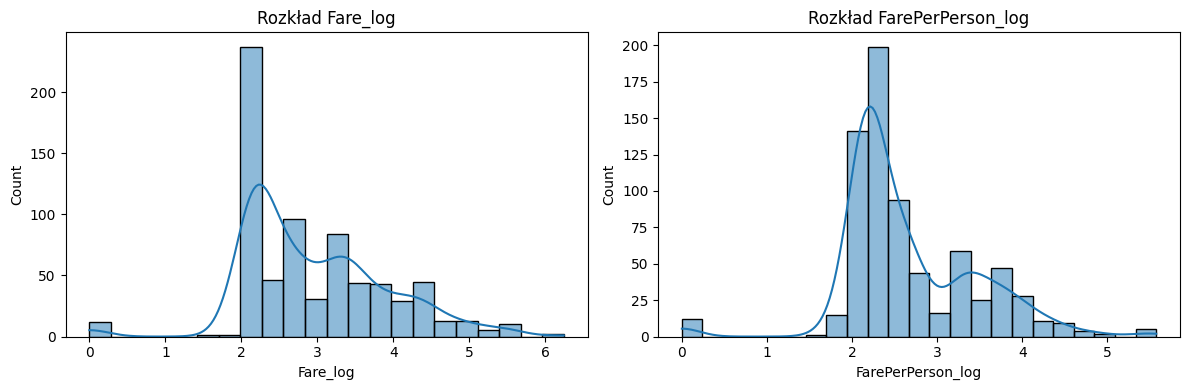

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df['Fare_log'], kde=True, ax=axes[0])
axes[0].set_title('Rozkład Fare_log')
sns.histplot(train_df['FarePerPerson_log'], kde=True, ax=axes[1])
axes[1].set_title('Rozkład FarePerPerson_log')
plt.tight_layout()
plt.show()

Sprawdzam korelację między Fare, FarePerPerson i ich wersjami log, żeby zdecydować, które z nich zostają w finalnym zbiorze cech.

In [116]:
train_df[['Fare', 'FarePerPerson', 'Fare_log', 'FarePerPerson_log']].corr()

,Fare,FarePerPerson,Fare_log,FarePerPerson_log
Fare,1.000000,0.875272,0.790954,0.717376
FarePerPerson,0.875272,1.000000,0.698442,0.802854
Fare_log,0.790954,0.698442,1.000000,0.872248
FarePerPerson_log,0.717376,0.802854,0.872248,1.000000


Ze względu na silną korelację między Fare, FarePerPerson i ich wersjami log,
finalny wybór między nimi odłożę do etapu modelowania - przy modelu liniowym użyję
prawdopodobnie tylko jednej pary (np. `FarePerPerson_log`, bo ma niższą skośność i węższy
zakres wartości), a przy modelu drzewiastym mogę zostawić więcej wariantów i ocenić
feature importance.

### Finalne sprawdzenie występowania braków w komurkach

In [117]:
missing_summary = train_df.isna().sum()
print("Braki w poszczególnych kolumnach (train):")
print(missing_summary)
print(f"\nCałkowita liczba brakujących wartości w train: {missing_summary.sum()}")

missing_summary_test = test_df.isna().sum()
print(f"\nCałkowita liczba brakujących wartości w test: {missing_summary_test.sum()}")

Braki w poszczególnych kolumnach (train):
Survived                           0
Pclass                             0
Sex                                0
Age                                0
Fare                               0
SocialGroup_Professional/Clergy    0
SocialGroup_Military/Nobility      0
FamilySize                         0
FamilySizeCategory_Small           0
FamilySizeCategory_Large           0
Embarked_Q                         0
Embarked_S                         0
HasCabin                           0
TicketGroupSize                    0
FarePerPerson                      0
Fare_log                           0
FarePerPerson_log                  0
dtype: int64

Całkowita liczba brakujących wartości w train: 0

Całkowita liczba brakujących wartości w test: 0


### Finalny zbiór

In [118]:
print(f"Finalna liczba kolumn: {train_df.shape[1]}")
print(f"Finalna liczba wierszy: {train_df.shape[0]}")

train_df.info()

Finalna liczba kolumn: 17
Finalna liczba wierszy: 712
<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 693 to 508
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Survived                         712 non-null    int64  
 1   Pclass                           712 non-null    int64  
 2   Sex                              712 non-null    int64  
 3   Age                              712 non-null    float64
 4   Fare                             712 non-null    float64
 5   SocialGroup_Professional/Clergy  712 non-null    bool   
 6   SocialGroup_Military/Nobility    712 non-null    bool   
 7   FamilySize                       712 non-null    int64  
 8   FamilySizeCategory_Small         712 non-null    bool   
 9   FamilySizeCategory_Large         712 non-null    bool   
 10  Embarked_Q                       712 non-null    bool   
 11  Embarked_S                       